In [4]:
using CSV, DataFrames, Plots
gr()

case_dir = joinpath(@__DIR__, "case_final")

# (subplot title, filename) for each snapshot. Rename the titles if the
# numbers mean something other than simulation time.
profiles = [
    ("(a) t = 5600 s",  "pressure_profile_5600.csv"),
    ("(b) t = 20000 s", "pressure_profile_20000.csv"),
    ("(c) t = 38000 s", "pressure_profile_38000.csv"),
]

# Column layout (1-based) in the LedaFlow export. Each pipe is stored as a
# (position [m], pressure [bara]) column pair; columns 9-14 hold Wellbore2-4
# and are not plotted. Line 2 is dashed because Line 1 and Line 2 nearly
# coincide, so this keeps both visible where they overlap.
series = [
    (label = "Mainline", pos = 5, val = 6, color = :steelblue,  ls = :solid, length=39000),
    (label = "Line 1",   pos = 1, val = 2, color = :darkorange, ls = :solid, length=9000),
    #(label = "Line 2",   pos = 3, val = 4, color = :seagreen,   ls = :dash, length=9000),
    (label = "Well 1",     pos = 7, val = 8, color = :crimson,    ls = :solid, length=1200),
]

3-element Vector{@NamedTuple{label::String, pos::Int64, val::Int64, color::Symbol, ls::Symbol, length::Int64}}:
 (label = "Mainline", pos = 5, val = 6, color = :steelblue, ls = :solid, length = 39000)
 (label = "Line 1", pos = 1, val = 2, color = :darkorange, ls = :solid, length = 9000)
 (label = "Well 1", pos = 7, val = 8, color = :crimson, ls = :solid, length = 1200)

In [5]:
# Read a LedaFlow profile export: ';' delimited, ',' decimal. Row 1 is the
# case name and row 2 is the units/name header, so data starts at row 3. The
# pipes have different lengths, so the short columns come in padded with
# `missing`.
read_profile(path) = CSV.read(path, DataFrame;
    header = false,
    skipto = 3,
    delim = ';',
    decimal = ',',
    types = Float64,
    silencewarnings = true,
)

# Pull out a (position, pressure) column pair, dropping the trailing missings.
function getxy(df, cpos, cval, length)
    x = df[!, cpos]; y = df[!, cval]
    x = length .- x # flip x-axis to show distance from outlet
    keep = .!(ismissing.(x) .| ismissing.(y))
    return Float64.(x[keep]), Float64.(y[keep])
end

# One subplot: every series plotted vs distance. 
# legend lives in a separate panel, so individual subplots draw no legend.
function profile_subplot(df, title; show_xlabel = false)
    p = plot(; title = title, legend = false,
             ylabel = "Pressure (bar)",
             xlabel = show_xlabel ? "Distance (m)" : "")
    for s in series
        x, y = getxy(df, s.pos, s.val, s.length)
        plot!(p, x, y; color = s.color, ls = s.ls, lw = 3)
    end
    return p
end

profile_subplot (generic function with 1 method)

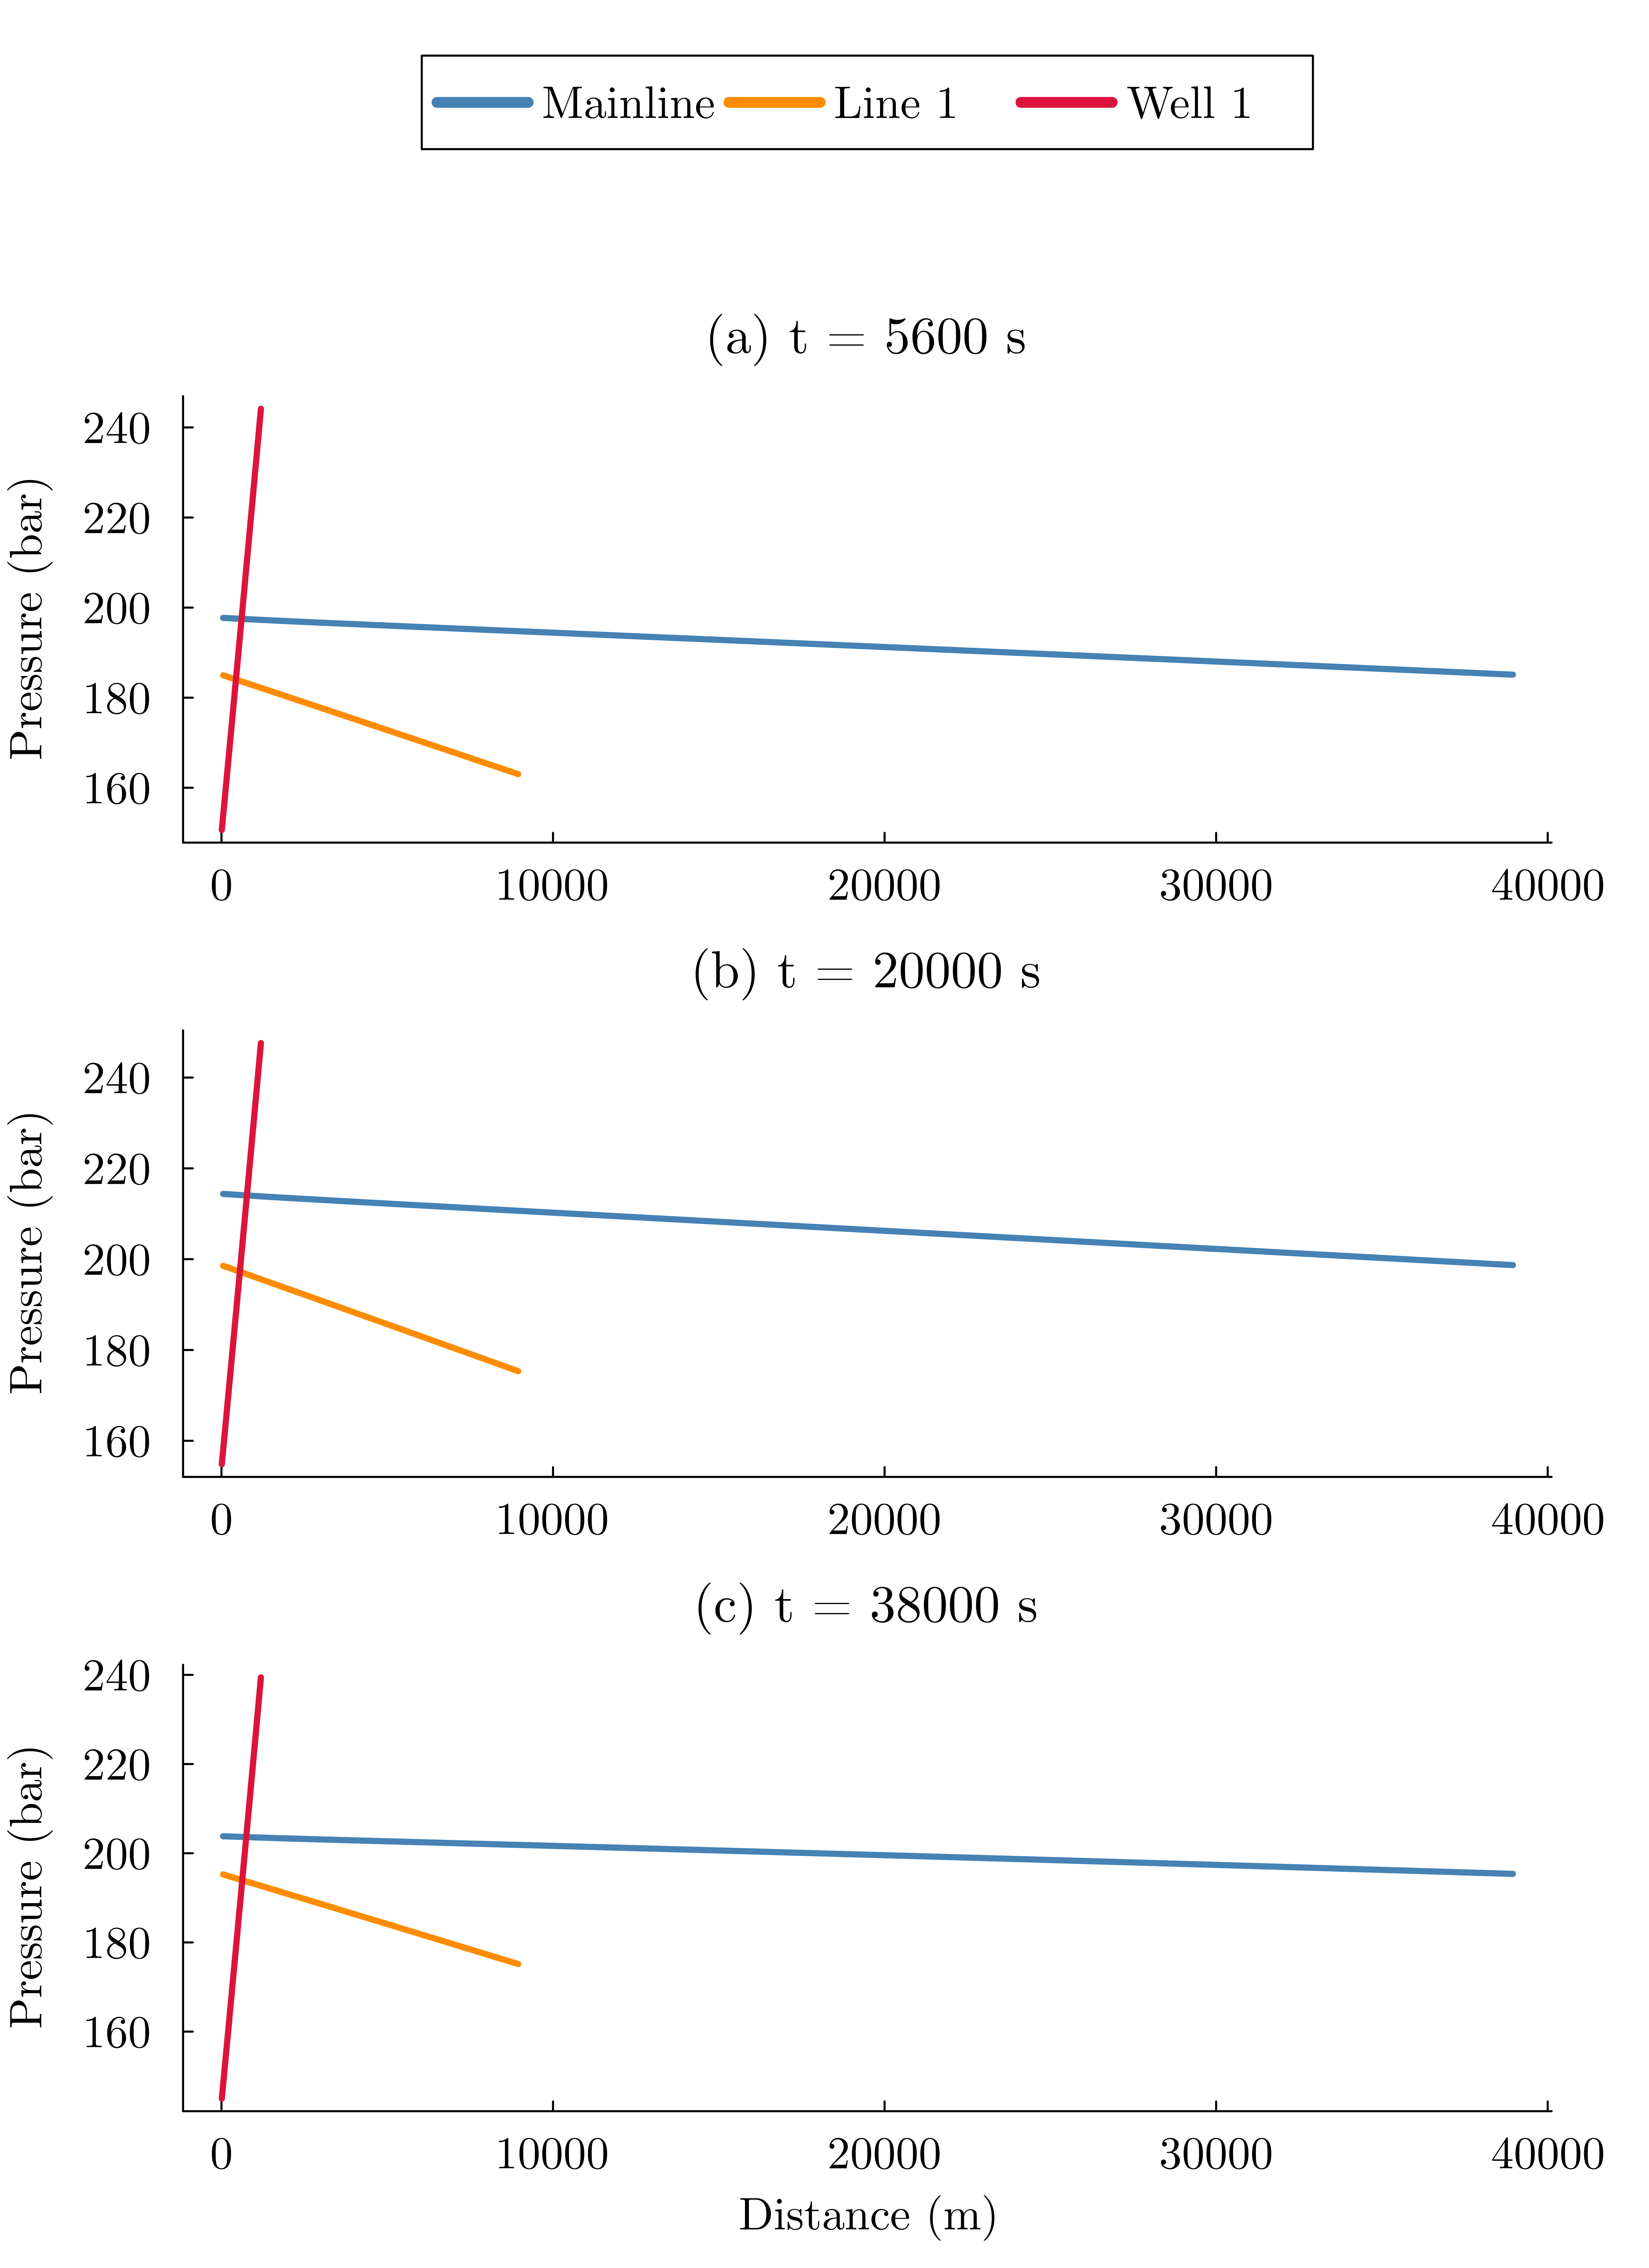

In [6]:
default(
    legendfont=(14, "Computer Modern"), 
    titlefont=(16, "Computer Modern", :bold), 
    tickfont=(14, "Computer Modern"), 
    guidefont=(14, "Computer Modern"),
    lw=3,
    yformatter=:plain,
    xformatter=:plain,
    grid=false,
    xlabel="Position (m)",
    dpi=750
)

dfs = [read_profile(joinpath(case_dir, f)) for (_, f) in profiles]

subs = [profile_subplot(df, t; show_xlabel = (i == length(profiles)))
        for (i, (df, (t, _))) in enumerate(zip(dfs, profiles))]

# Dedicated panel holding the single legend shared by all three subplots.
legpanel = plot(; legend = :bottom, framestyle = :none, grid = false,
                legend_columns = length(series))
for s in series
    plot!(legpanel, [NaN], [NaN]; color = s.color, ls = s.ls, lw = 3, label = s.label)
end

lay = @layout [leg{0.07h}; grid(3, 1)]
fig = plot(legpanel, subs...; layout = lay, size = (800, 1100),
           left_margin = 5Plots.mm, right_margin = 10Plots.mm)

savefig(fig, joinpath(@__DIR__, "pressure_profile_comparison.png"))
fig